Need imports first 

In [1]:
from __future__ import print_function
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from astropy.io import fits
from glob import glob
from astropy.time import Time
from astropy import coordinates as coords
from astropy import units as u
from astropy import constants as const
from astropy import convolution as conv
from astropy.table import Table, Column
import scipy.interpolate as scinterp
import time
start = time.time()

#import wdatmos
import spec_plot_tools as spt
import cal_params as cp

print(os.getcwd())

/Users/BenKaiser/Desktop/radial_velocity_calculations


Now I'm going to try to import plot_spec.py, which is more dangerous because it has executable things in it normally. I tried to comment out the file_setting so I think that means it won't actually "do" anything...

In [2]:
import plot_spec as ps

all_avg


Oh, sweet, I just had to define it to be a string I hadn't defined. We're looking good now I think. The next major hurdle will be that the default plotting method is to put them into plt.whatever instead of fig.whatever, so it's not building a figure object as far as I know, which is what one would want.

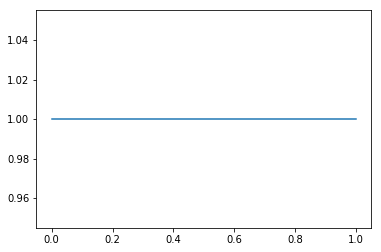

In [3]:
plt.plot([1,1])
plt.show()

Ok, that also answers my question as to whether I have to mess with some setting to have plots display inline.

In [4]:
target_dir= '/Users/BenKaiser/Desktop/GaiaJ1644m0449_paper/'
target_spec_file='ravg_fwctb.GaiaJ1644m0449_20190729_400m1.fits'
target_spec_file2='ravg_fwctb.GaiaJ1644m0449_20190825_tellcorr_400m2.fits'
model_spec_file='J1644_fit_flambda.dms'
#target_spec_file= glob(target_dir+target_spec_file)
#model_spec_file= glob(target_dir+model_spec_file)
print(target_spec_file)
print(model_spec_file)

ravg_fwctb.GaiaJ1644m0449_20190729_400m1.fits
J1644_fit_flambda.dms


I guess I have to just change the working directory instead of using a long file path for whatever reason...

In [5]:
os.chdir(target_dir)

In [6]:
target_spec, header, target_noise= spt.retrieve_spec(target_spec_file)
target_spec2,header2, target_noise2=spt.retrieve_spec(target_spec_file2)

In [7]:
print(os.getcwd())

/Users/BenKaiser/Desktop/GaiaJ1644m0449_paper


In [8]:
model_spec= spt.retrieve_model_spec(model_spec_file)

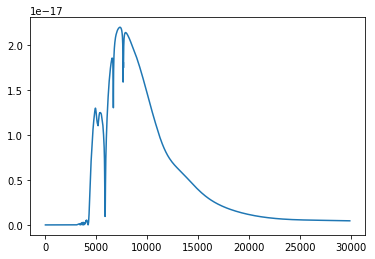

In [9]:
plt.plot(model_spec[0],model_spec[1])
plt.show()

In [10]:
print(model_spec)

[[  4.00000000e+01   4.04000000e+01   4.08000000e+01 ...,   2.93178000e+04
    2.96110000e+04   2.99071000e+04]
 [  4.26815400e-36   4.18405400e-36   4.10241600e-36 ...,   4.70899900e-19
    4.64192100e-19   4.57065100e-19]]


I need to convert the flux values of the model though to also be in 1 e-16 units since that's what the target is in

In [11]:
model_spec[1]=model_spec[1]*1e16

In [12]:
og_model=np.copy(model_spec)

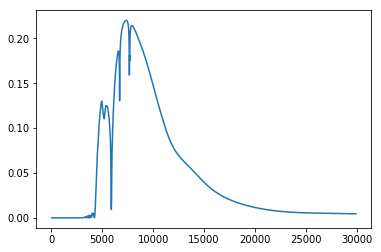

In [13]:
plt.plot(model_spec[0],model_spec[1])
plt.show()

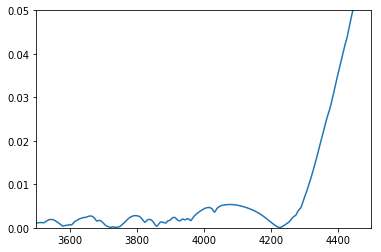

In [14]:
plt.plot(og_model[0],og_model[1])
plt.xlim(3500,4500)
#plt.yscale('log')
plt.ylim(0,0.05)
plt.show()

In [15]:
model_spec=spt.clean_spectrum(model_spec, np.nanmin(target_spec[0]), np.nanmax(target_spec[0]),[])

I want to smooth the target spectrum slightly to make it easier to see since it's so noisy

In [16]:
#sm_target_spec= ps.convolve_spectrum(target_spec, header, kernel_type='box', pix_width=3)
#sm_target_spec2=ps.convolve_spectrum(target_spec2, header2, kernel_type='box',pix_width=3)
sm_target_spec= ps.convolve_spectrum(target_spec, header, kernel_type='gaussian', pix_width=header['SEE_SIG'])
sm_target_spec2=ps.convolve_spectrum(target_spec2, header2, kernel_type='gaussian',pix_width=header2['SEE_SIG'])

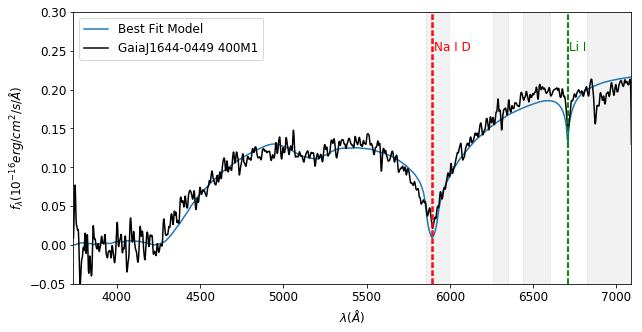

In [17]:
plt.rc('font',size=12)
fig= plt.figure(figsize=(10,5))
label_pos=0.25
label_off=10
plt.plot(model_spec[0],model_spec[1], label='Best Fit Model')
plt.plot(sm_target_spec[0],sm_target_spec[1], label="GaiaJ1644-0449 400M1", color='k')
plt.xlim(np.nanmin(target_spec[0]), np.nanmax(target_spec[0]))
plt.ylim(-0.05, 0.3)
plt.axvline(x=5889.950866765008, linestyle='--', color='r')
plt.axvline(x=5895.9241497669427, linestyle='--', color='r')
plt.text(5895.9241497669427+label_off, label_pos,'Na I D', color='r')

plt.axvline(x=6707.7580436285689, linestyle='--', color='g')
plt.axvline(x=6707.9080032878719, linestyle='--', color='g')
plt.text(6707.9080032878719+label_off, label_pos,'Li I', color='g')

plt.ylabel(r'$f_{\lambda} (10^{-16} erg/ cm^{2}/s/ \AA)$')
plt.xlabel(r'$\lambda(\AA)$')
#spt.show_plot(line_id='alkali', label_pos=0.25, convert_to_air=True)
spt.show_plot(line_id='')

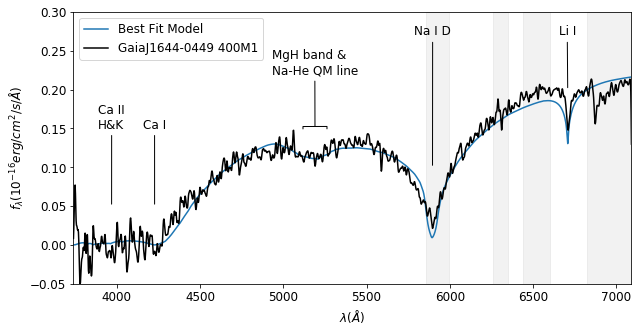

In [18]:
plt.rc('font',size=12)
fig= plt.figure(figsize=(10,5))
label_pos=0.27
label_pos2= 0.15
label_off=110
plt.plot(model_spec[0],model_spec[1], label='Best Fit Model')
plt.plot(sm_target_spec[0],sm_target_spec[1], label="GaiaJ1644-0449 400M1", color='k')
plt.xlim(np.nanmin(target_spec[0]), np.nanmax(target_spec[0]))
plt.ylim(-0.05, 0.3)


plt.annotate('Na I D',xy=(5895.9241497669427, 0.1),xytext=(5895.9241497669427-label_off, label_pos), arrowprops=dict(arrowstyle='-'))
plt.annotate('Li I',xy=(6707.9080032878719, 0.2),xytext=(6707.9080032878719-55, label_pos), arrowprops=dict(arrowstyle='-'))
plt.annotate('Ca II\nH&K',xy=(3968.4672118153667, 0.05),xytext=(3968.4672118153667-80, label_pos2), arrowprops=dict(arrowstyle='-'))
plt.annotate('Ca I',xy=(4226.7295809531952, 0.05),xytext=(4226.7295809531952-70, label_pos2), arrowprops=dict(arrowstyle='-'))
plt.annotate('MgH band &\nNa-He QM line',xy=(5190, 0.15),xytext=(5190-260, label_pos-0.05), arrowprops=dict(arrowstyle='-['))





plt.ylabel(r'$f_{\lambda} (10^{-16} erg/ cm^{2}/s/ \AA)$')
plt.xlabel(r'$\lambda(\AA)$')
#spt.show_plot(line_id='alkali', label_pos=0.25, convert_to_air=True)
spt.show_plot(line_id='')

/Users/BenKaiser/Desktop/Goodman_ref_files/line_lists/alkali_lines_vac.csv
wavelengths.min:  5891.583264
new_wavelengths.min(): 5889.95086677
wavelengths.min:  5897.558147
new_wavelengths.min(): 5895.92414977
wavelengths.min:  6709.61
new_wavelengths.min(): 6707.75804363
wavelengths.min:  6709.76
new_wavelengths.min(): 6707.90800329
wavelengths.min:  7667.008906
new_wavelengths.min(): 7664.899016
wavelengths.min:  7701.083536
new_wavelengths.min(): 7698.96445153
wavelengths.min:  8185.5054
new_wavelengths.min(): 8183.25551561
wavelengths.min:  8197.0434
new_wavelengths.min(): 8194.79039837
wavelengths.min:  8197.0766
new_wavelengths.min(): 8194.8235894


/Users/BenKaiser/.virtualenvs/stars/lib/python2.7/site-packages/matplotlib/axes/_axes.py:545: UserWarning: No labelled objects found. Use label='...' kwarg on individual plots.
  warnings.warn("No labelled objects found. "


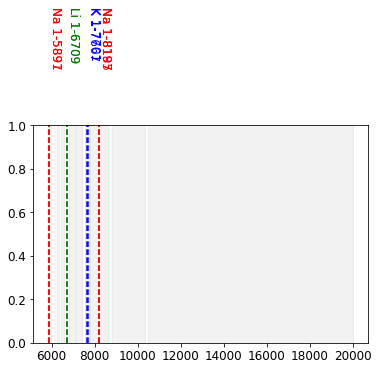

In [19]:
spt.show_plot(line_id='alkali', convert_to_air=True)

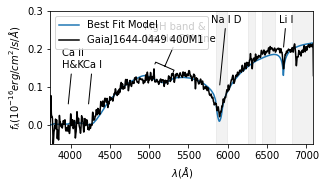

In [20]:
plt.rc('font',size=10)
fig= plt.figure(figsize=(4.72,2.44)) #from v1 description image size
label_pos=0.27
label_pos2= 0.15
label_off=110
plt.plot(model_spec[0],model_spec[1], label='Best Fit Model')
plt.plot(sm_target_spec[0],sm_target_spec[1], label="GaiaJ1644-0449 400M1", color='k')
plt.xlim(np.nanmin(target_spec[0]), np.nanmax(target_spec[0]))
plt.ylim(-0.05, 0.3)


plt.annotate('Na I D',xy=(5895.9241497669427, 0.1),xytext=(5895.9241497669427-label_off, label_pos), arrowprops=dict(arrowstyle='-'))
plt.annotate('Li I',xy=(6707.9080032878719, 0.2),xytext=(6707.9080032878719-55, label_pos), arrowprops=dict(arrowstyle='-'))
plt.annotate('Ca II\nH&K',xy=(3968.4672118153667, 0.05),xytext=(3968.4672118153667-80, label_pos2), arrowprops=dict(arrowstyle='-'))
plt.annotate('Ca I',xy=(4226.7295809531952, 0.05),xytext=(4226.7295809531952-70, label_pos2), arrowprops=dict(arrowstyle='-'))
plt.annotate('MgH band &\nNa-He QM line',xy=(5190, 0.15),xytext=(5190-260, label_pos-0.05), arrowprops=dict(arrowstyle='-['))





plt.ylabel(r'$f_{\lambda} (10^{-16} erg/ cm^{2}/s/ \AA)$')
plt.xlabel(r'$\lambda(\AA)$')
#spt.show_plot(line_id='alkali', label_pos=0.25, convert_to_air=True)
spt.show_plot(line_id='')

Well that didn't work... and I don't think that it actually will....

However, in the word doc it says the image original height was 4.61" and width was 8.92", so...

In [21]:
print(4.61/5.)
print(8.92/10.)

0.922
0.892


I guess there's some sort of margin that gets trimmed...

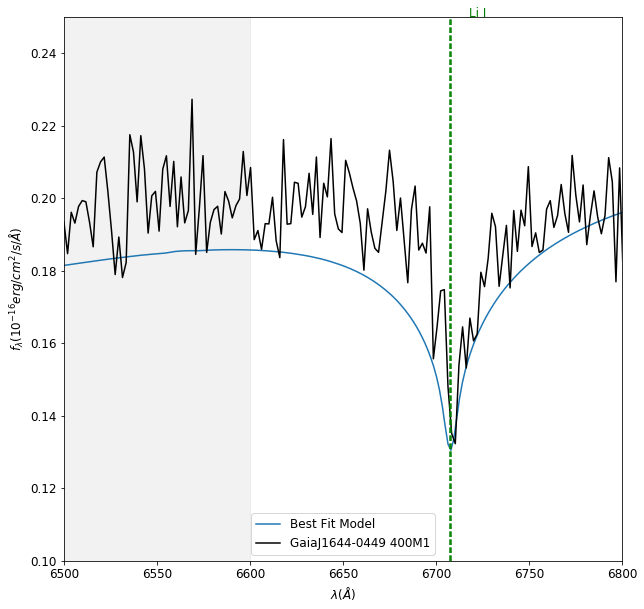

In [22]:
plt.rc('font',size=12)
fig= plt.figure(figsize=(10,10))
label_pos=0.25
label_off=10
plt.plot(model_spec[0],model_spec[1], label='Best Fit Model')
plt.plot(target_spec[0],target_spec[1], label="GaiaJ1644-0449 400M1", color='k')
plt.xlim(6500, 6800)
plt.ylim(0.1, 0.25)
#plt.axvline(x=5889.950866765008, linestyle='--', color='r')
#plt.axvline(x=5895.9241497669427, linestyle='--', color='r')
#plt.text(5895.9241497669427+label_off, label_pos,'Na I D', color='r')

plt.axvline(x=6707.7580436285689, linestyle='--', color='g')
plt.axvline(x=6707.9080032878719, linestyle='--', color='g')
plt.text(6707.9080032878719+label_off, label_pos,'Li I', color='g')

plt.ylabel(r'$f_{\lambda} (10^{-16} erg/ cm^{2}/s/ \AA)$')
plt.xlabel(r'$\lambda(\AA)$')
#spt.show_plot(line_id='alkali', label_pos=0.25, convert_to_air=True)
spt.show_plot(line_id='')

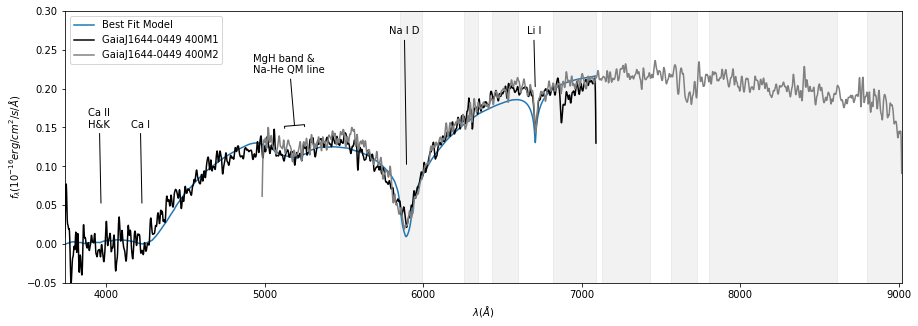

In [23]:
plt.rc('font',size=10)
fig= plt.figure(figsize=(15,5)) #from v1 description image size
label_pos=0.27
label_pos2= 0.15
label_off=110
plt.plot(model_spec[0],model_spec[1], label='Best Fit Model')
plt.plot(sm_target_spec[0],sm_target_spec[1], label="GaiaJ1644-0449 400M1", color='k')
plt.plot(sm_target_spec2[0],sm_target_spec2[1],label="GaiaJ1644-0449 400M2", color='grey')
plt.xlim(np.nanmin(target_spec[0]), np.nanmax(target_spec2[0]))
plt.ylim(-0.05, 0.3)


plt.annotate('Na I D',xy=(5895.9241497669427, 0.1),xytext=(5895.9241497669427-label_off, label_pos), arrowprops=dict(arrowstyle='-'))
plt.annotate('Li I',xy=(6707.9080032878719, 0.2),xytext=(6707.9080032878719-55, label_pos), arrowprops=dict(arrowstyle='-'))
plt.annotate('Ca II\nH&K',xy=(3968.4672118153667, 0.05),xytext=(3968.4672118153667-80, label_pos2), arrowprops=dict(arrowstyle='-'))
plt.annotate('Ca I',xy=(4226.7295809531952, 0.05),xytext=(4226.7295809531952-70, label_pos2), arrowprops=dict(arrowstyle='-'))
plt.annotate('MgH band &\nNa-He QM line',xy=(5190, 0.15),xytext=(5190-260, label_pos-0.05), arrowprops=dict(arrowstyle='-['))





plt.ylabel(r'$f_{\lambda} (10^{-16} erg/ cm^{2}/s/ \AA)$')
plt.xlabel(r'$\lambda(\AA)$')
#spt.show_plot(line_id='alkali', label_pos=0.25, convert_to_air=True)
spt.show_plot(line_id='')

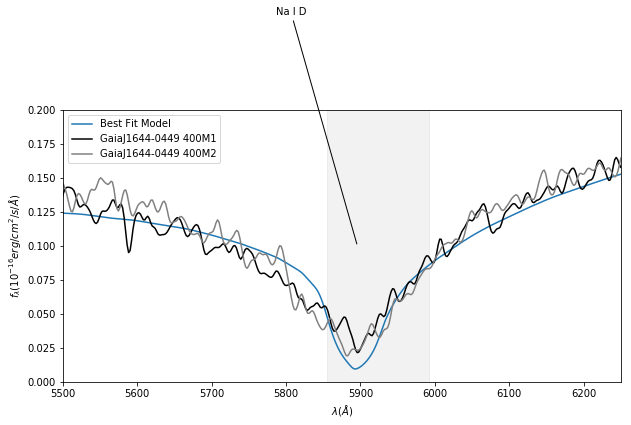

In [24]:
plt.rc('font',size=10)
fig= plt.figure(figsize=(10,5)) #from v1 description image size
label_pos=0.27
label_pos2= 0.15
label_off=110
plt.plot(model_spec[0],model_spec[1], label='Best Fit Model')
plt.plot(sm_target_spec[0],sm_target_spec[1], label="GaiaJ1644-0449 400M1", color='k')
plt.plot(sm_target_spec2[0],sm_target_spec2[1],label="GaiaJ1644-0449 400M2", color='grey')
plt.xlim(5500,6250)
plt.ylim(0.0, 0.2)


plt.annotate('Na I D',xy=(5895.9241497669427, 0.1),xytext=(5895.9241497669427-label_off, label_pos), arrowprops=dict(arrowstyle='-'))
#plt.annotate('Li I',xy=(6707.9080032878719, 0.2),xytext=(6707.9080032878719-55, label_pos), arrowprops=dict(arrowstyle='-'))
#plt.annotate('Ca II\nH&K',xy=(3968.4672118153667, 0.05),xytext=(3968.4672118153667-80, label_pos2), arrowprops=dict(arrowstyle='-'))
#plt.annotate('Ca I',xy=(4226.7295809531952, 0.05),xytext=(4226.7295809531952-70, label_pos2), arrowprops=dict(arrowstyle='-'))
#plt.annotate('MgH band &\nNa-He QM line',xy=(5190, 0.15),xytext=(5190-260, label_pos-0.05), arrowprops=dict(arrowstyle='-['))





plt.ylabel(r'$f_{\lambda} (10^{-16} erg/ cm^{2}/s/ \AA)$')
plt.xlabel(r'$\lambda(\AA)$')
#spt.show_plot(line_id='alkali', label_pos=0.25, convert_to_air=True)
spt.show_plot(line_id='')

In [25]:
trim_spot=6800
tsm_target_spec=spt.clean_spectrum(sm_target_spec,np.min(sm_target_spec[0]), trim_spot,[])
tsm_target_spec2=spt.clean_spectrum(sm_target_spec2,trim_spot, np.max(sm_target_spec2[0]),[])
tmodel_spec=spt.clean_spectrum(og_model, np.nanmin(target_spec[0]), np.nanmax(target_spec2[0]),[])

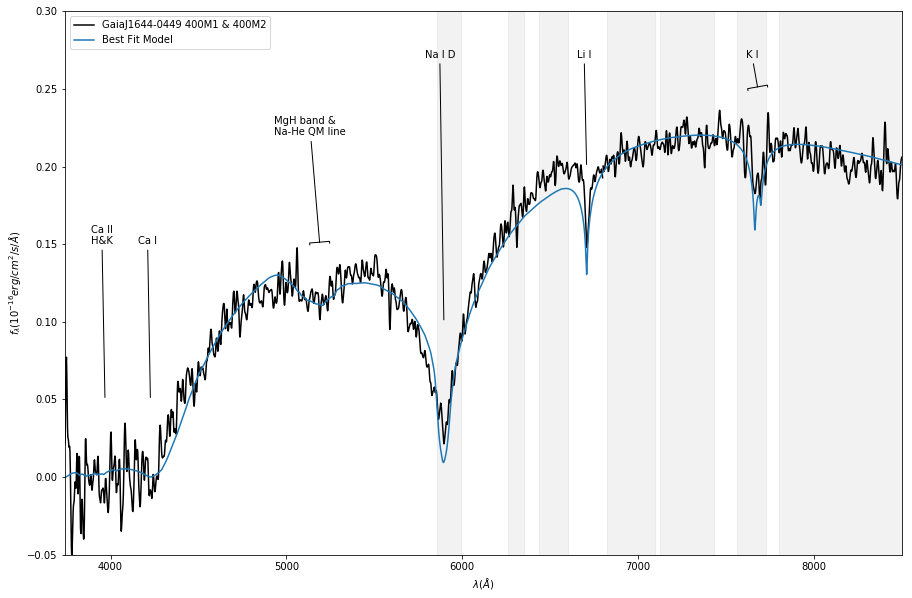

In [26]:
plt.rc('font',size=10)
fig= plt.figure(figsize=(15,10)) #from v1 description image size
label_pos=0.27
label_pos2= 0.15
label_off=110
plt.plot(tsm_target_spec[0],tsm_target_spec[1], label="GaiaJ1644-0449 400M1 & 400M2", color='k')
plt.plot(tsm_target_spec2[0],tsm_target_spec2[1], color='k')
plt.plot(tmodel_spec[0],tmodel_spec[1], label='Best Fit Model')
plt.xlim(np.nanmin(target_spec[0]), 8500)
plt.ylim(-0.05, 0.3)

k_spot=np.mean([7664.899016,7698.96445153])


plt.annotate('Na I D',xy=(5895.9241497669427, 0.1),xytext=(5895.9241497669427-label_off, label_pos), arrowprops=dict(arrowstyle='-'))
plt.annotate('Li I',xy=(6707.9080032878719, 0.2),xytext=(6707.9080032878719-55, label_pos), arrowprops=dict(arrowstyle='-'))
plt.annotate('Ca II\nH&K',xy=(3968.4672118153667, 0.05),xytext=(3968.4672118153667-80, label_pos2), arrowprops=dict(arrowstyle='-'))
plt.annotate('Ca I',xy=(4226.7295809531952, 0.05),xytext=(4226.7295809531952-70, label_pos2), arrowprops=dict(arrowstyle='-'))
plt.annotate('MgH band &\nNa-He QM line',xy=(5190, 0.15),xytext=(5190-260, label_pos-0.05), arrowprops=dict(arrowstyle='-['))
plt.annotate('K I',xy=(k_spot, 0.25),xytext=(k_spot-70, label_pos), arrowprops=dict(arrowstyle='-['))






plt.ylabel(r'$f_{\lambda} (10^{-16} erg/ cm^{2}/s/ \AA)$')
plt.xlabel(r'$\lambda(\AA)$')
#spt.show_plot(line_id='alkali', label_pos=0.25, convert_to_air=True)
spt.show_plot(line_id='')

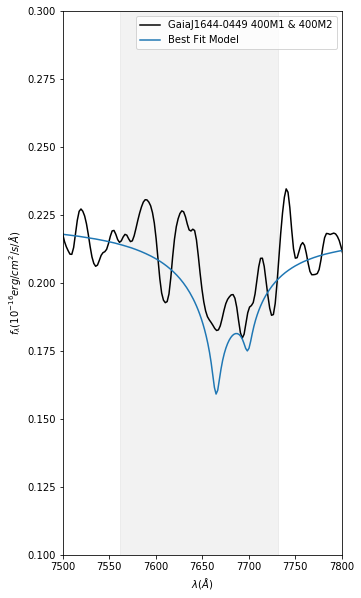

In [27]:
plt.rc('font',size=10)
fig= plt.figure(figsize=(5,10)) #from v1 description image size
label_pos=0.27
label_pos2= 0.15
label_off=110
plt.plot(tsm_target_spec[0],tsm_target_spec[1], label="GaiaJ1644-0449 400M1 & 400M2", color='k')
plt.plot(tsm_target_spec2[0],tsm_target_spec2[1], color='k')
plt.plot(tmodel_spec[0],tmodel_spec[1], label='Best Fit Model')
plt.xlim(7500,7800)
plt.ylim(0.1, 0.3)


#plt.annotate('Na I D',xy=(5895.9241497669427, 0.1),xytext=(5895.9241497669427-label_off, label_pos), arrowprops=dict(arrowstyle='-'))
#plt.annotate('Li I',xy=(6707.9080032878719, 0.2),xytext=(6707.9080032878719-55, label_pos), arrowprops=dict(arrowstyle='-'))
#plt.annotate('Ca II\nH&K',xy=(3968.4672118153667, 0.05),xytext=(3968.4672118153667-80, label_pos2), arrowprops=dict(arrowstyle='-'))
#plt.annotate('Ca I',xy=(4226.7295809531952, 0.05),xytext=(4226.7295809531952-70, label_pos2), arrowprops=dict(arrowstyle='-'))
#plt.annotate('MgH band &\nNa-He QM line',xy=(5190, 0.15),xytext=(5190-260, label_pos-0.05), arrowprops=dict(arrowstyle='-['))





plt.ylabel(r'$f_{\lambda} (10^{-16} erg/ cm^{2}/s/ \AA)$')
plt.xlabel(r'$\lambda(\AA)$')
#spt.show_plot(line_id='alkali', label_pos=0.25, convert_to_air=True)
spt.show_plot(line_id='')

## 2020-05-29 Because I'm an idiot I want to mess with plotting the unsmoothed spectrum versus the model. fucking moron.

In [28]:
trim_spot=6800
tsm_target_spec=spt.clean_spectrum(target_spec,np.min(target_spec[0]), trim_spot,[])
tsm_target_spec2=spt.clean_spectrum(target_spec2,trim_spot, np.max(target_spec2[0]),[])
tmodel_spec=spt.clean_spectrum(og_model, np.nanmin(target_spec[0]), np.nanmax(target_spec2[0]),[])

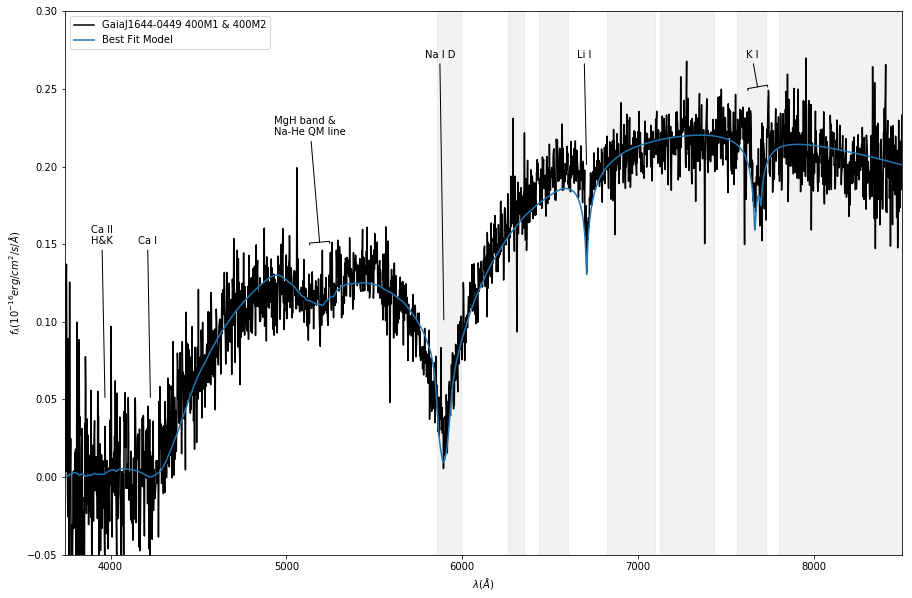

In [29]:
plt.rc('font',size=10)
fig= plt.figure(figsize=(15,10)) #from v1 description image size
label_pos=0.27
label_pos2= 0.15
label_off=110
plt.plot(tsm_target_spec[0],tsm_target_spec[1], label="GaiaJ1644-0449 400M1 & 400M2", color='k')
plt.plot(tsm_target_spec2[0],tsm_target_spec2[1], color='k')
plt.plot(tmodel_spec[0],tmodel_spec[1], label='Best Fit Model')
plt.xlim(np.nanmin(target_spec[0]), 8500)
plt.ylim(-0.05, 0.3)

k_spot=np.mean([7664.899016,7698.96445153])


plt.annotate('Na I D',xy=(5895.9241497669427, 0.1),xytext=(5895.9241497669427-label_off, label_pos), arrowprops=dict(arrowstyle='-'))
plt.annotate('Li I',xy=(6707.9080032878719, 0.2),xytext=(6707.9080032878719-55, label_pos), arrowprops=dict(arrowstyle='-'))
plt.annotate('Ca II\nH&K',xy=(3968.4672118153667, 0.05),xytext=(3968.4672118153667-80, label_pos2), arrowprops=dict(arrowstyle='-'))
plt.annotate('Ca I',xy=(4226.7295809531952, 0.05),xytext=(4226.7295809531952-70, label_pos2), arrowprops=dict(arrowstyle='-'))
plt.annotate('MgH band &\nNa-He QM line',xy=(5190, 0.15),xytext=(5190-260, label_pos-0.05), arrowprops=dict(arrowstyle='-['))
plt.annotate('K I',xy=(k_spot, 0.25),xytext=(k_spot-70, label_pos), arrowprops=dict(arrowstyle='-['))





#plt.xlim(6000,8000)
plt.ylabel(r'$f_{\lambda} (10^{-16} erg/ cm^{2}/s/ \AA)$')
plt.xlabel(r'$\lambda(\AA)$')
#spt.show_plot(line_id='alkali', label_pos=0.25, convert_to_air=True)
spt.show_plot(line_id='')

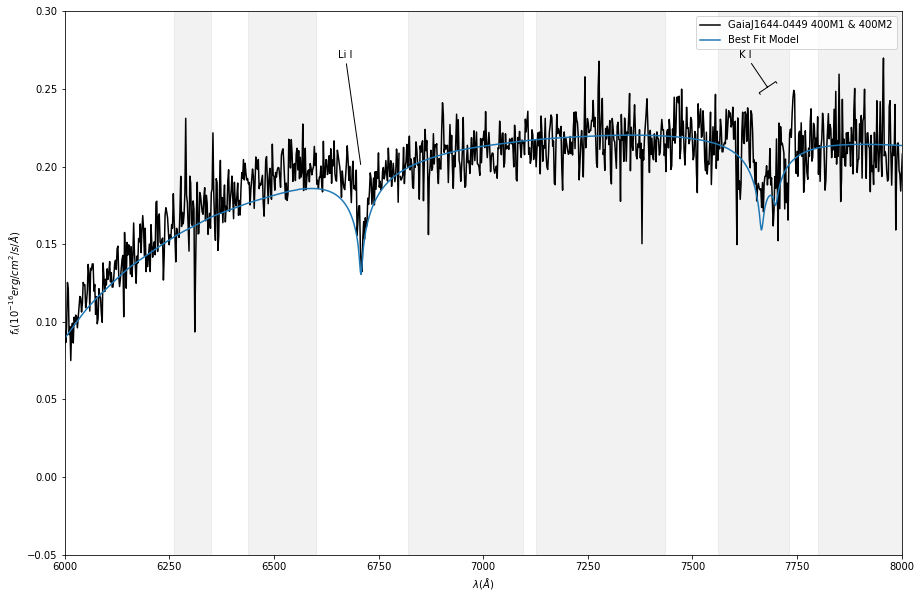

In [30]:
plt.rc('font',size=10)
fig= plt.figure(figsize=(15,10)) #from v1 description image size
label_pos=0.27
label_pos2= 0.15
label_off=110
plt.plot(tsm_target_spec[0],tsm_target_spec[1], label="GaiaJ1644-0449 400M1 & 400M2", color='k')
plt.plot(tsm_target_spec2[0],tsm_target_spec2[1], color='k')
plt.plot(tmodel_spec[0],tmodel_spec[1], label='Best Fit Model')
plt.xlim(np.nanmin(target_spec[0]), 8500)
plt.ylim(-0.05, 0.3)

k_spot=np.mean([7664.899016,7698.96445153])


#plt.annotate('Na I D',xy=(5895.9241497669427, 0.1),xytext=(5895.9241497669427-label_off, label_pos), arrowprops=dict(arrowstyle='-'))
plt.annotate('Li I',xy=(6707.9080032878719, 0.2),xytext=(6707.9080032878719-55, label_pos), arrowprops=dict(arrowstyle='-'))
#plt.annotate('Ca II\nH&K',xy=(3968.4672118153667, 0.05),xytext=(3968.4672118153667-80, label_pos2), arrowprops=dict(arrowstyle='-'))
#plt.annotate('Ca I',xy=(4226.7295809531952, 0.05),xytext=(4226.7295809531952-70, label_pos2), arrowprops=dict(arrowstyle='-'))
#plt.annotate('MgH band &\nNa-He QM line',xy=(5190, 0.15),xytext=(5190-260, label_pos-0.05), arrowprops=dict(arrowstyle='-['))
plt.annotate('K I',xy=(k_spot, 0.25),xytext=(k_spot-70, label_pos), arrowprops=dict(arrowstyle='-['))





plt.xlim(6000,8000)
plt.ylabel(r'$f_{\lambda} (10^{-16} erg/ cm^{2}/s/ \AA)$')
plt.xlabel(r'$\lambda(\AA)$')
#spt.show_plot(line_id='alkali', label_pos=0.25, convert_to_air=True)
spt.show_plot(line_id='')

# 2020-06-15 I want the model to actually match the observation, meaning that since I'm smoothing the observation, I need to smooth the model by the same amount since Simon's stuff previously was fit to the default resolution.

I need to verify that Simon's model spectrum is roughly evenly spaced in wavelength

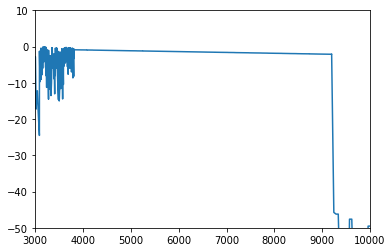

In [38]:
plt.plot(og_model[0][1:],(np.roll(og_model[0],1)-og_model[0])[1:])
plt.ylim([-50,10])
plt.xlim([3000,10000])
plt.show()

Ok. So Simon's model points are not evenly spaced...So I guess I have to interpolate them to be evenly spaced and then I can do the convolution

In [39]:
new_model_res=0.1
new_model_waves=np.arange(3000,10000,new_model_res)
new_model=np.array([new_model_waves,np.interp(new_model_waves,og_model[0],og_model[1])])

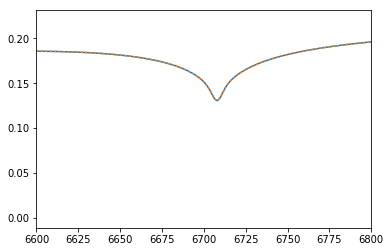

In [47]:
plt.plot(og_model[0],og_model[1])
plt.plot(new_model[0],new_model[1], linestyle=':')
plt.xlim([6600,6800])
plt.show()

Ok. So the interpolated version appears to overlay the original model spectrum well enough.

In [48]:
obs_dlambda=target_spec[0][2]-target_spec[0][1]
print(obs_dlambda)

1.99943623566


In [107]:
sm_width=header['SEE_SIG']
model_sm_width=sm_width*obs_dlambda/new_model_res
sm_target_spec= ps.convolve_spectrum(target_spec, header, kernel_type='gaussian', pix_width=sm_width,kernel_width=3.2/0.3)
sm_target_spec2=ps.convolve_spectrum(target_spec2, header2, kernel_type='gaussian',pix_width=sm_width,kernel_width=3.2/0.3)
sm_model=ps.convolve_spectrum(new_model, header, kernel_type='gaussian',pix_width=model_sm_width, kernel_width=3.2/0.3*obs_dlambda/new_model_res)
sm_model=ps.convolve_spectrum(sm_model,header, kernel_type='box',pix_width=obs_dlambda/new_model_res)

In [108]:
print(sm_width)
print(model_sm_width)
print(3.2/0.3*obs_dlambda/new_model_res)
print(obs_dlambda/new_model_res)

1.75282802561
35.0466786929
213.27319847
19.9943623566


In [109]:
trim_spot=6800
tsm_target_spec=spt.clean_spectrum(sm_target_spec,np.min(sm_target_spec[0]), trim_spot,[])
tsm_target_spec2=spt.clean_spectrum(sm_target_spec2,trim_spot, np.max(sm_target_spec2[0]),[])
tmodel_spec=spt.clean_spectrum(sm_model, np.nanmin(target_spec[0]), np.nanmax(target_spec2[0]),[])

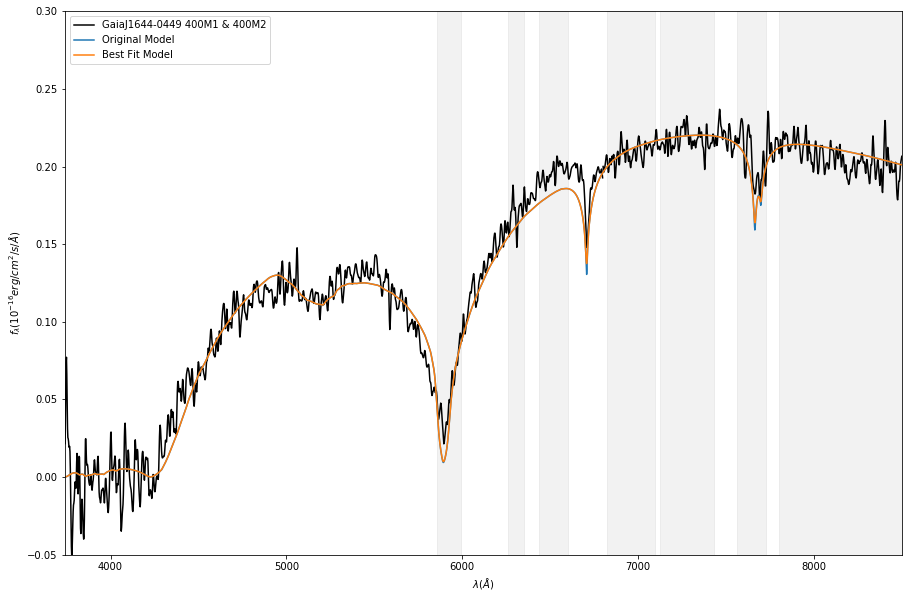

In [110]:
plt.rc('font',size=10)
fig= plt.figure(figsize=(15,10)) #from v1 description image size
label_pos=0.27
label_pos2= 0.15
label_off=110
plt.plot(tsm_target_spec[0],tsm_target_spec[1], label="GaiaJ1644-0449 400M1 & 400M2", color='k')
plt.plot(tsm_target_spec2[0],tsm_target_spec2[1], color='k')
plt.plot(og_model[0],og_model[1], label='Original Model')
plt.plot(tmodel_spec[0],tmodel_spec[1], label='Best Fit Model')


plt.xlim(np.nanmin(target_spec[0]), 8500)
plt.ylim(-0.05, 0.3)

k_spot=np.mean([7664.899016,7698.96445153])


#plt.annotate('Na I D',xy=(5895.9241497669427, 0.1),xytext=(5895.9241497669427-label_off, label_pos), arrowprops=dict(arrowstyle='-'))
#plt.annotate('Li I',xy=(6707.9080032878719, 0.2),xytext=(6707.9080032878719-55, label_pos), arrowprops=dict(arrowstyle='-'))
#plt.annotate('Ca II\nH&K',xy=(3968.4672118153667, 0.05),xytext=(3968.4672118153667-80, label_pos2), arrowprops=dict(arrowstyle='-'))
#plt.annotate('Ca I',xy=(4226.7295809531952, 0.05),xytext=(4226.7295809531952-70, label_pos2), arrowprops=dict(arrowstyle='-'))
#plt.annotate('MgH band &\nNa-He QM line',xy=(5190, 0.15),xytext=(5190-260, label_pos-0.05), arrowprops=dict(arrowstyle='-['))
#plt.annotate('K I',xy=(k_spot, 0.25),xytext=(k_spot-70, label_pos), arrowprops=dict(arrowstyle='-['))




#plt.xlim([6600,6800])

plt.ylabel(r'$f_{\lambda} (10^{-16} erg/ cm^{2}/s/ \AA)$')
plt.xlabel(r'$\lambda(\AA)$')
#spt.show_plot(line_id='alkali', label_pos=0.25, convert_to_air=True)
spt.show_plot(line_id='')

Ok. I give up. I do not know what's wrong with my convolutions here, but pretty clearly they are not working the same way that Simon's did before. Therefore, I think it would be prudent to switch the figure to be the unsmoothed version perhaps? No... Chris was content with the smoothed version previously. Why are you messing with this?? Just let it go dumbass.

## Go do the other god damn parts of the paper!